# SPV - Projeto Monitoramento Postural
**Grupo 4**

## 1. Ambiente de Execução
O Sistema de Processamento Visual (SPV) foi desenvolvido em linguagem Python, utilizando a biblioteca OpenCV, conforme especificado pelo trabalho , e executado no ambiente interativo Jupyter Notebook.

O sistema realiza a análise de imagens de perfil de usuários sentados, identificando pontos-chave do corpo humano (como cabeça, ombros e quadril) para auxiliar na avaliação postural.

## 2. Requisitos Necessários

Antes de iniciar, é necessário ter instalado:

* Python 3.x
* Jupyter Notebook
* Webcam funcional
* Bibliotecas Python:
  * numpy
  * opencv-python (cv2)
  * mediapipe
  * matplotlib

Crie uma pasta para o laboratório (ex: LabA) e coloque nela:

O arquivo .ipynb (notebook do projeto) \
As imagens que serão utilizadas

### Instalação das dependências
No caso de uso local ou Colab, execute:

```
pip install opencv-python mediapipe numpy
```



In [1]:
pip install opencv-python mediapipe numpy


  Using cached mediapipe-0.10.33-py3-none-win_amd64.whl.metadata (9.8 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sounddevice-0.5.5-py3-none-win_amd64.whl.metadata (1.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached mediapipe-0.10.33-py3-none-win_amd64.whl (10.6 MB)
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
Using cached sounddevice-0.5.5-py3-none-win_amd64.whl (365 kB)
Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl (46.5 MB)

   ---------------------------------------- 0/5 [flatbuffers]
   -------- ------------------------------- 1/5 [opencv-contrib-python]
   -------- ------------------------------- 1/5 [opencv-contrib-python]
   -------- ------------------------------- 1/5 [opencv-contrib-python]
   -------- ------------

## 3. Procedimento de Execução
**Passo 1: Abrir o ambiente**

No Jupyter Notebook ou Google Colab \
Abrir o arquivo .ipynb contendo o código

**Passo 2: Executar as células iniciais**

Executar as células responsáveis por:

* Importação das bibliotecas
* Definição das funções (draw_keypoints e process_image)

**Passo 3: Executar a função principal**

O usuário deve chamar a função:

```
process_image("imagem.jpg", "saida.jpg")
```

Onde:

* "imagem.jpg" → imagem de entrada
* "saida.jpg" → nome do arquivo gerado


## 4. Funcionamento do Sistema
Ao executar a função process_image, o sistema realiza automaticamente:

**1.Leitura da imagem**

A imagem é carregada utilizando OpenCV.

**2.Conversão de cor**

A imagem é convertida de BGR para RGB, formato exigido pelo MediaPipe.

**3.Carregamento do modelo**

O sistema verifica se o modelo de detecção de pose existe localmente:

Caso não exista, ele é baixado automaticamente da internet
Isso permite que o usuário não precise configurar manualmente o modelo

**4.Detecção da pose humana**

Utilizando o MediaPipe (Tasks API), o sistema identifica os pontos do corpo.

**5.Mapeamento dos pontos relevantes**

São extraídos pontos específicos:

* Nariz (cabeça)
* Ombros esquerdo e direito
* Quadril esquerdo e direito

Esses pontos são usados como referência para análise postural.

**6.Desenho das estruturas**

O sistema desenha:

* Pontos de referência (em verde)
* Linhas da coluna (ombro → quadril)
* Linha da cabeça (nariz → ombros)

**7.Geração do resultado visual**

O sistema gera uma imagem final contendo:

* Lado esquerdo → imagem original
* Lado direito → imagem com marcações

**8.Exibição da imagem**
No Colab: exibida diretamente no notebook
Localmente: exibida em uma janela

**9.Salvamento do resultado**

A imagem processada é automaticamente salva no arquivo especificado:

saida.jpg

In [2]:
import cv2 as cv
import matplotlib.pyplot as plt

def plot_histograms(original, processed):

    # Converter para escala de cinza (contraste)
    gray_original = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
    gray_processed = cv.cvtColor(processed, cv.COLOR_BGR2GRAY)

    # Calcular histogramas
    hist_original = cv.calcHist([gray_original], [0], None, [256], [0, 256])
    hist_processed = cv.calcHist([gray_processed], [0], None, [256], [0, 256])

    # Plot
    plt.figure(figsize=(12,5))

    # ORIGINAL
    plt.subplot(1,2,1)
    plt.bar(range(256), hist_original.flatten(), color='blue', edgecolor='gray')
    plt.title('Histograma - Imagem Original')
    plt.xlabel('Intensidade (0-255)')
    plt.ylabel('Quantidade de Pixels')
    plt.xlim([-1,256])
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # PROCESSADA
    plt.subplot(1,2,2)
    plt.bar(range(256), hist_processed.flatten(), color='red', edgecolor='gray')
    plt.title('Histograma - Imagem Processada')
    plt.xlabel('Intensidade (0-255)')
    plt.ylabel('Quantidade de Pixels')
    plt.xlim([-1,256])
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

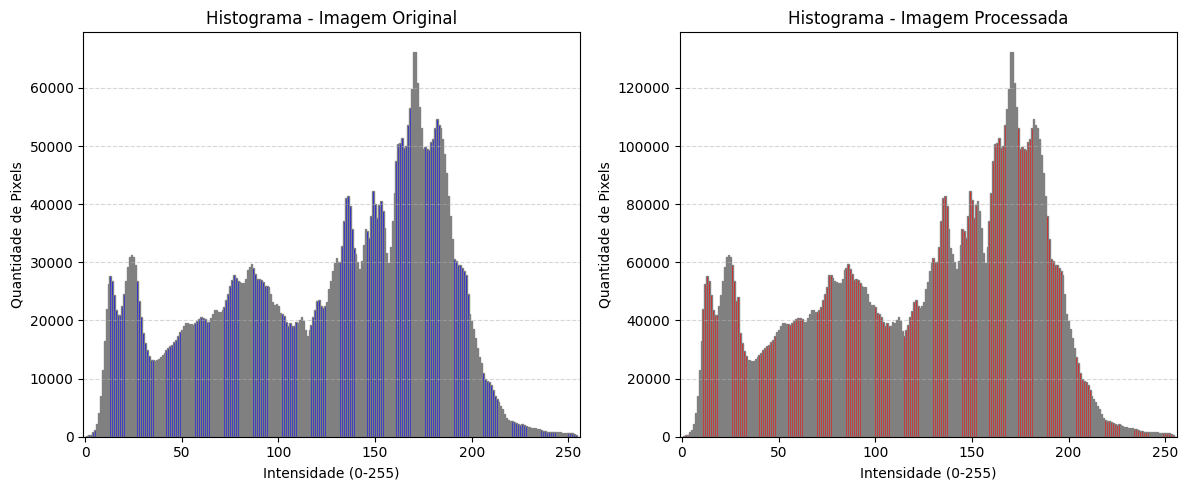

In [3]:
img_original = cv.imread('postura_incorreta.jpg')
img_processada = cv.imread('saida_postura_incorreta.png')

plot_histograms(img_original, img_processada)

Modelo $YCbCr$

In [7]:
def rgb_to_ycbcr(rgb_img):
    # Coeficientes do livro (Seção 4.3.4)
    transform_mat = np.array([[0.299, 0.587, 0.114],
                              [-0.1687, -0.3313, 0.5],
                              [0.5, -0.4187, -0.0813]])
    # Ajuste de offset para Cb e Cr (normalmente 128 em 8 bits)
    ycbcr = rgb_img @ transform_mat.T
    ycbcr[:,:,1:] += 0.5
    return np.clip(ycbcr, 0, 1)

In [8]:
img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB) /255.0

NameError: name 'cv2' is not defined

In [6]:
if 'img_rgb' in locals() and img_rgb is not None:
    # Aplicar a função rgb_to_ycbcr
    ycbcr_img = rgb_to_ycbcr(img_rgb)

    # Separar os canais Y, Cb e Cr
    Y_channel = ycbcr_img[:, :, 0]
    Cb_channel = ycbcr_img[:, :, 1]
    Cr_channel = ycbcr_img[:, :, 2]

    # Plotar a imagem original e os canais separados
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title('Imagem RGB Original')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(Y_channel, cmap='gray')
    plt.title('Y Channel (Luminancia)')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(Cb_channel, cmap='RdBu') # Red-Blue para Cb
    plt.title('Cb Crominancia (Blue-Yellow)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(Cr_channel, cmap='PiYG') # Pink-Yellow-Green para Cr
    plt.title('Cr Crominancia (Red-Green)')
    plt.axis('off')

    plt.show()
else:
    print("Erro: 'img_rgb' não está definida. Por favor, carregue a imagem RGB primeiro.")

Erro: 'img_rgb' não está definida. Por favor, carregue a imagem RGB primeiro.


In [9]:
import cv2
import mediapipe as mp
import numpy as np
import cv2_imshow

# For mediapipe.tasks
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import os
import urllib.request

def draw_keypoints(image, pose_landmarks_list):
    if not pose_landmarks_list:
        return image

    landmarks = pose_landmarks_list[0] # Assuming one person

    h, w, _ = image.shape

    # Using integer indices directly as mediapipe.solutions is not available
    pontos = {
        "nose": 0,  # Corresponds to mp.solutions.pose.PoseLandmark.NOSE
        "left_shoulder": 11, # Corresponds to mp.solutions.pose.PoseLandmark.LEFT_SHOULDER
        "right_shoulder": 12, # Corresponds to mp.solutions.pose.PoseLandmark.RIGHT_SHOULDER
        "left_hip": 23, # Corresponds to mp.solutions.pose.PoseLandmark.LEFT_HIP
        "right_hip": 24 # Corresponds to mp.solutions.pose.PoseLandmark.RIGHT_HIP
    }

    coords = {}

    for nome, idx in pontos.items():
        lm = landmarks[idx]
        x, y = int(lm.x * w), int(lm.y * h)
        coords[nome] = (x, y)

        cv2.circle(image, (x, y), 6, (0, 255, 0), -1)
        cv2.putText(image, nome, (x+5, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    # linhas principais
    cv2.line(image, coords["left_shoulder"], coords["left_hip"], (255,0,0), 2)
    cv2.line(image, coords["right_shoulder"], coords["right_hip"], (255,0,0), 2)

    ombro_medio = (
        int((coords["left_shoulder"][0] + coords["right_shoulder"][0]) / 2),
        int((coords["left_shoulder"][1] + coords["right_shoulder"][1]) / 2)
    )

    cv2.line(image, coords["nose"], ombro_medio, (0,0,255), 2)

    return image


def process_image(path, output_path="resultado.jpg"):
    image = cv2.imread(path)

    if image is None:
        print("Erro ao carregar imagem")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Download the pose landmarker model if not exists
    model_path = 'pose_landmarker_lite.task'
    if not os.path.exists(model_path):
        print(f"Downloading {model_path}...")
        url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task"
        urllib.request.urlretrieve(url, model_path)
        print(f"{model_path} downloaded.")

    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        output_segmentation_masks=False,
        running_mode=vision.RunningMode.IMAGE
    )
    detector = vision.PoseLandmarker.create_from_options(options)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)

    if detection_result.pose_landmarks:
        # Create a copy for annotation
        annotated_image = image.copy()

        # Draw custom keypoints
        annotated_image = draw_keypoints(annotated_image, detection_result.pose_landmarks)

        combined = np.hstack((image, annotated_image))

        try:
            cv2_imshow(combined)
        except:
            cv2.imshow("Resultado", combined)
            cv2.waitKey(0)
            cv2.destroyAllWindows()

        # salvar imagem
        cv2.imwrite(output_path, combined)
        print(f"Imagem salva em: {output_path}")

    else:
        print("Nenhuma pose detectada")

ModuleNotFoundError: No module named 'cv2_imshow'

In [ ]:
process_image('postura_incorreta.jpg', 'saida_postura_incorreta.png')

Imagem salva em: saida_postura_incorreta.png


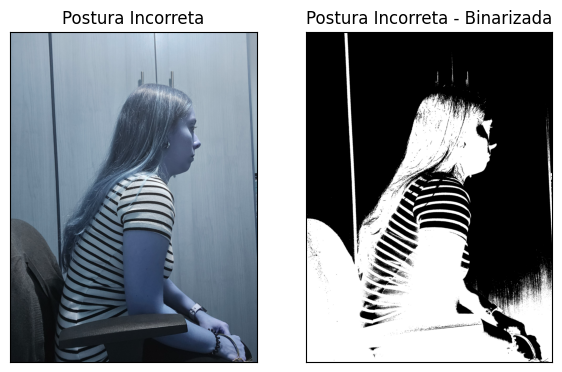

In [10]:
import plotly.express as px
import matplotlib.pyplot as plt 
img = cv2.imread('postura_incorreta.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_ori = img.copy()
# PASSO 2. Binarização (Limiarização de Otsu)
ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
plt.figure(figsize=(7,7))
plt.subplot(121),plt.imshow(img,"gray"),plt.title('Postura Incorreta')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(thresh,"gray"),plt.title('Postura Incorreta - Binarizada')
plt.xticks([]), plt.yticks([])
plt.show()


In [11]:
# EXEMPLO COMPLETO DE SEGMENTAÇÃO POR WATERSHED
#

import cv2
import numpy as np

# 1. Carregar imagem e converter para escala de cinza
img = cv2.imread('postura_incorreta.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Binarização (Limiarização de Otsu)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 3. Remoção de ruído (Morfologia)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# 4. Transformada de Distância
# Calculamos a distância de cada pixel branco ao pixel preto mais próximo
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# 5. Obter o "Foreground de Certeza"
# Pegamos apenas os picos da transformada de distância
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# 6. Marcadores para o Watershed
sure_fg = np.uint8(sure_fg)
ret, markers = cv2.connectedComponents(sure_fg)

# Adicionamos 1 a todos os labels para que o fundo seja 1 e não 0
markers = markers + 1
# Marcamos a região desconhecida (fronteiras) como 0
unknown = cv2.subtract(cv2.dilate(opening, kernel, iterations=3), sure_fg)
markers[unknown == 255] = 0

# 7. Aplicar Watershed
markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0] # Bordas em vermelho

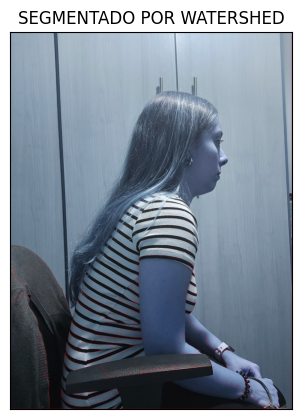

In [12]:
# Mostrar imagens:
plt.figure(figsize=(8,5))
plt.subplot(122),plt.imshow(img,"gray"),plt.title('SEGMENTADO POR WATERSHED')
plt.xticks([]),plt.yticks([])
plt.show()

In [13]:
# escreve um arquivo de imagem com img transformada
cv2.imwrite('saida_trat.png', img)

True

Tetentativa de pegar a postura com a imagem tratada usando whatershed

Aplicando segmentação Watershed...
Sucesso! Resultado salvo em saida_final.png


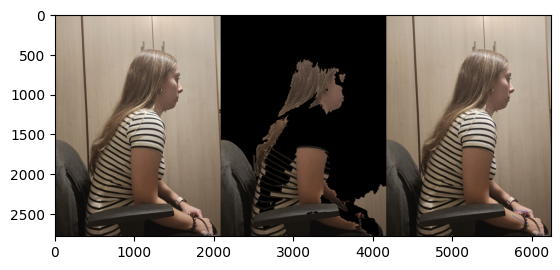

In [14]:
import cv2
import mediapipe as mp
import numpy as np
import os
import urllib.request
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def apply_watershed_segmentation(img):
    # 1. Pré-processamento: Tons de Cinza e Suavização
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0) # Ajuda a remover ruído
    
    # 2. Binarização (Otsu)
    # ATENÇÃO: A complexidade do fundo torna isso muito difícil!
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # 3. Limpeza morfológica
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # 4. Transformada de Distância
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    
    # --- CORREÇÃO CRÍTICA AQUI! ---
    # Mudamos de 0.7 para 0.05 (ou até menos) para pegar o corpo todo
    _, sure_fg = cv2.threshold(dist_transform, 0.05 * dist_transform.max(), 255, 0)
    
    # 5. Marcadores para o Watershed
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    
    # 6. Watershed
    markers = cv2.watershed(img, markers)
    
    # Criar máscara
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    mask[markers > 1] = 255 
    
    # Aplicar a máscara
    segmented_img = cv2.bitwise_and(img, img, mask=mask)
    return segmented_img

def draw_keypoints(image, pose_landmarks_list):
    if not pose_landmarks_list:
        return image
    landmarks = pose_landmarks_list[0]
    h, w, _ = image.shape

    pontos = {
        "nariz": 0, "ombro_esq": 11, "ombro_dir": 12,
        "quadril_esq": 23, "quadril_dir": 24
    }

    coords = {}
    for nome, idx in pontos.items():
        lm = landmarks[idx]
        x, y = int(lm.x * w), int(lm.y * h)
        coords[nome] = (x, y)
        cv2.circle(image, (x, y), 6, (0, 255, 0), -1)

    # Linhas posturais
    cv2.line(image, coords["ombro_esq"], coords["quadril_esq"], (255, 0, 0), 2)
    cv2.line(image, coords["ombro_dir"], coords["quadril_dir"], (255, 0, 0), 2)
    
    ombro_medio = (
        int((coords["ombro_esq"][0] + coords["ombro_dir"][0]) / 2),
        int((coords["ombro_esq"][1] + coords["ombro_dir"][1]) / 2)
    )
    cv2.line(image, coords["nariz"], ombro_medio, (0, 0, 255), 2)

    return image

def process_image(path, output_path="resultado.jpg"):
    image = cv2.imread(path)
    if image is None:
        print(f"Erro ao carregar '{path}'")
        return

    # Executa a segmentação PDI (Técnica tradicional)
    print("Aplicando segmentação Watershed...")
    image_segmented = apply_watershed_segmentation(image)

    # Configuração do MediaPipe
    model_path = 'pose_landmarker_lite.task'
    if not os.path.exists(model_path):
        url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task"
        urllib.request.urlretrieve(url, model_path)

    options = vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=model_path),
        running_mode=vision.RunningMode.IMAGE
    )
    detector = vision.PoseLandmarker.create_from_options(options)

    # Tenta detecção na segmentada
    image_rgb_seg = cv2.cvtColor(image_segmented, cv2.COLOR_BGR2RGB)
    mp_image_seg = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb_seg)
    detection_result = detector.detect(mp_image_seg)

    # Fallback (Plano B): Tenta na original se a segmentada falhar
    if not detection_result.pose_landmarks:
        print("Pose não detectada na segmentada. Tentando original (Fallback)...")
        image_rgb_orig = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mp_image_orig = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb_orig)
        detection_result = detector.detect(mp_image_orig)

    if detection_result.pose_landmarks:
        annotated_image = image.copy()
        annotated_image = draw_keypoints(annotated_image, detection_result.pose_landmarks)
        
        # Painel: Original | Segmentada PDI | Analisada
        res_seg = cv2.resize(image_segmented, (image.shape[1], image.shape[0]))
        combined = np.hstack((image, res_seg, annotated_image))
        
        cv2.imwrite(output_path, combined)
        plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
        print(f"Sucesso! Resultado salvo em {output_path}")
    else:
        print("Infelizmente, nenhuma pose foi detectada.")

# --- EXECUÇÃO ---
# Certifique-se de que o arquivo 'postura_incorreta.jpg' está na mesma pasta!
process_image('postura_incorreta.jpg', 'saida_final.png')

Tetentativa de pegar a postura com a imagem tratada usando a segmentação do mediapipe

Sucesso Total! Resultado salvo em ia_mulher_sentada_saida_final_mp.png


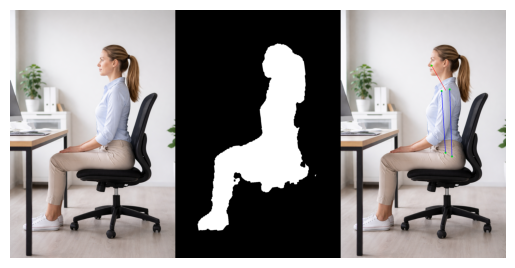

In [15]:
import cv2
import mediapipe as mp
import numpy as np
import os
import urllib.request
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def draw_keypoints(image, pose_landmarks_list):
    if not pose_landmarks_list:
        return image
    landmarks = pose_landmarks_list[0]
    h, w, _ = image.shape

    pontos = {
        "nariz": 0, "ombro_esq": 11, "ombro_dir": 12,
        "quadril_esq": 23, "quadril_dir": 24
    }

    coords = {}
    for nome, idx in pontos.items():
        lm = landmarks[idx]
        x, y = int(lm.x * w), int(lm.y * h)
        coords[nome] = (x, y)
        cv2.circle(image, (x, y), 6, (0, 255, 0), -1)

    # Linhas posturais
    cv2.line(image, coords["ombro_esq"], coords["quadril_esq"], (255, 0, 0), 2)
    cv2.line(image, coords["ombro_dir"], coords["quadril_dir"], (255, 0, 0), 2)
    
    ombro_medio = (
        int((coords["ombro_esq"][0] + coords["ombro_dir"][0]) / 2),
        int((coords["ombro_esq"][1] + coords["ombro_dir"][1]) / 2)
    )
    cv2.line(image, coords["nariz"], ombro_medio, (0, 0, 255), 2)

    return image

def process_image_mp_mask(path, output_path="resultado.jpg"):
    image = cv2.imread(path)
    if image is None:
        print(f"Erro ao carregar '{path}'")
        return
    h, w, _ = image.shape

    # Configuração do MediaPipe - AGORA HABILITANDO SEGMENTAÇÃO!
    model_path = 'pose_landmarker_lite.task'
    if not os.path.exists(model_path):
        url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task"
        urllib.request.urlretrieve(url, model_path)

    options = vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=model_path),
        running_mode=vision.RunningMode.IMAGE,
        # --- ATENÇÃO: ESSA É A CHAVE ---
        output_segmentation_masks=True 
    )
    detector = vision.PoseLandmarker.create_from_options(options)

    # Tenta detecção na original
    image_rgb_orig = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image_orig = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb_orig)
    result = detector.detect(mp_image_orig)

    if result.pose_landmarks and result.segmentation_masks:
        # 1. Obtém a Máscara de Segmentação
        segmentation_mask = result.segmentation_masks[0].numpy_view()
        
        # 2. Converte para uma máscara binária (Transformação de Formato)
        # O MediaPipe gera valores flutuantes entre 0 (fundo) e 1 (corpo).
        # Normalizamos e binarizamos.
        mask = (segmentation_mask > 0.1).astype(np.uint8) * 255 # Ajuste suave de threshold

        # 3. PDI: Aplica a Máscara na Original
        # A máscara é apenas [h, w], precisamos do 3º canal.
        mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
        image_segmented = cv2.bitwise_and(image, mask_3ch) # Aplica a máscara na imagem original

        annotated_image = image.copy()
        annotated_image = draw_keypoints(annotated_image, result.pose_landmarks)
        
        # Painel: Original | Máscara | Analisada
        combined = np.hstack((image, mask_3ch, annotated_image))
        
        cv2.imwrite(output_path, combined)
        plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        print(f"Sucesso Total! Resultado salvo em {output_path}")

        # retorna os lanndimarks para análise posterior (se necessário)
        return result.pose_landmarks, mask
    else:
        print("Infelizmente, nenhuma pose foi detectada.")
        return None, None

# --- EXECUÇÃO ---
# Certifique-se de que o arquivo 'postura_incorreta.jpg' está na mesma pasta!
landmarks_correta, mask = process_image_mp_mask('ia_mulher_sentada.png', 'ia_mulher_sentada_saida_final_mp.png')


Sucesso Total! Resultado salvo em postura_incorreta_saida_final_mp.png


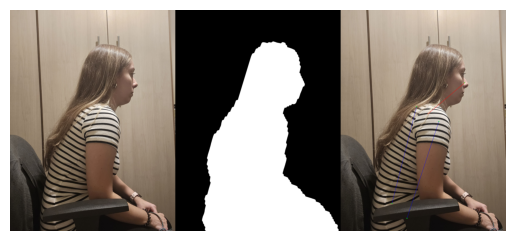

In [16]:
landmarks_incorreta, mask = process_image_mp_mask('postura_incorreta.jpg', 'postura_incorreta_saida_final_mp.png')

Histograma da imagem segmentada

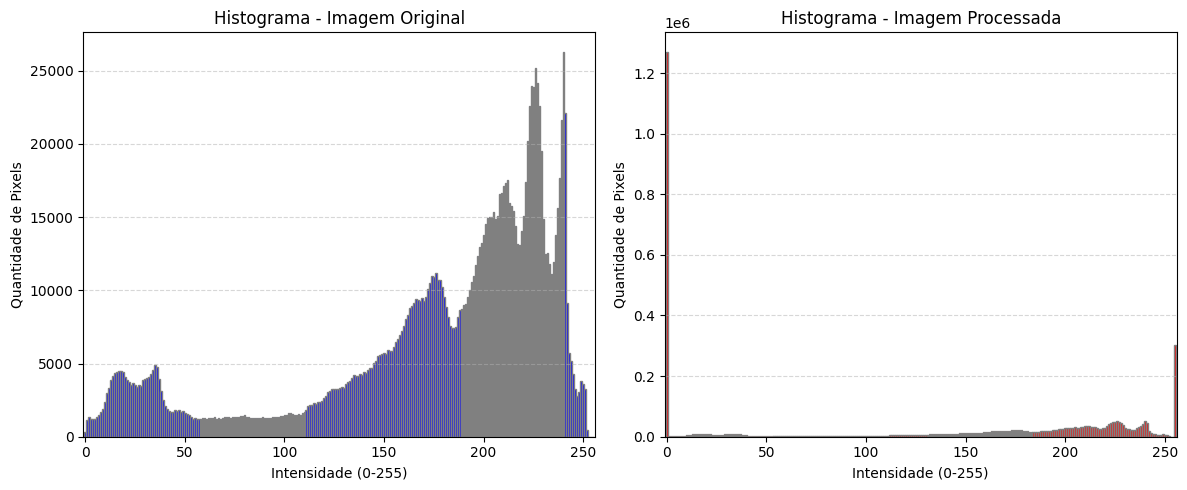

In [17]:
img1 = cv.imread('ia_mulher_sentada.png')
img2 = cv.imread('saida_final_mp.png')

plot_histograms(img1, img2)


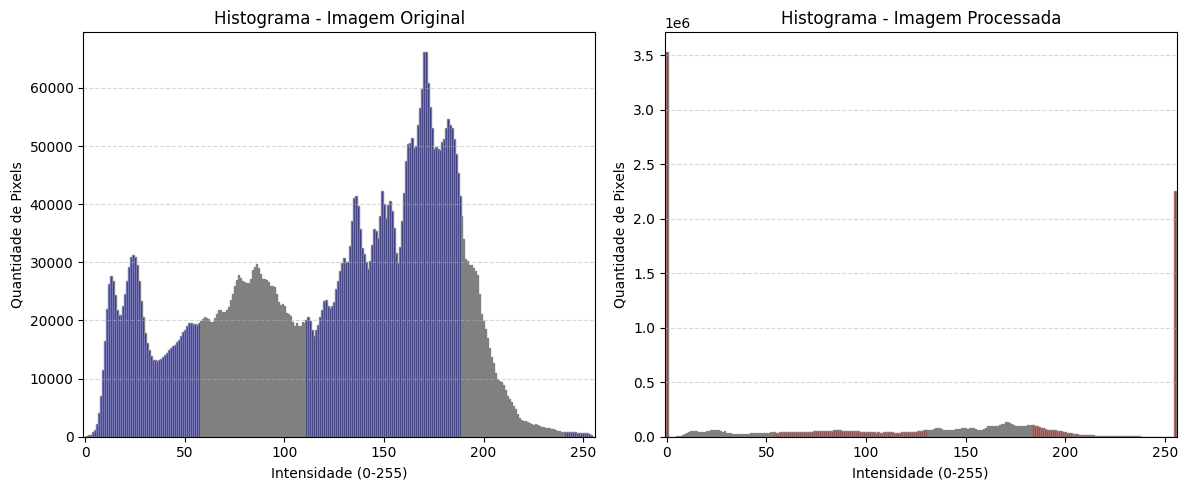

In [18]:
ima1 = cv.imread('postura_incorreta.jpg')
ima2 = cv.imread('postura_incorreta_saida_final_mp.png')
plot_histograms(ima1, ima2)

In [ ]:
landmarks_incorreta

[[NormalizedLandmark(x=0.7489703297615051, y=0.33300507068634033, z=-0.10744225978851318, visibility=0.9983263611793518, presence=0.9953879714012146, name=None),
  NormalizedLandmark(x=0.7224150896072388, y=0.30199873447418213, z=-0.11747852712869644, visibility=0.9986562728881836, presence=0.9954110980033875, name=None),
  NormalizedLandmark(x=0.7162107229232788, y=0.301826536655426, z=-0.11806764453649521, visibility=0.9985570311546326, presence=0.9958570599555969, name=None),
  NormalizedLandmark(x=0.7086275219917297, y=0.3021288514137268, z=-0.11852788180112839, visibility=0.9989672899246216, presence=0.9956383109092712, name=None),
  NormalizedLandmark(x=0.7229375839233398, y=0.3034610152244568, z=-0.18044571578502655, visibility=0.9982469081878662, presence=0.9949769377708435, name=None),
  NormalizedLandmark(x=0.7177146673202515, y=0.3041192889213562, z=-0.180526465177536, visibility=0.9980193376541138, presence=0.9950417876243591, name=None),
  NormalizedLandmark(x=0.7118778824

In [19]:
# retorna que a postura esta incorreta ou correta dependendo da posição dos pontos
def check_posture(landmarks):
    if not landmarks:
        return "Nenhuma pose detectada"

    for lm in landmarks:
        print(f"Landmark: {lm}")

        # Indices chave 
        nose = lm[0]  # Nariz
        left_shoulder = lm[11]  # Ombro esquerdo
        right_shoulder = lm[12]  # Ombro direito
        left_hip = lm[23]  # Quadril esquerdo
        right_hip = lm[24]  # Quadril direito
        # Verificar se os ombros estão alinhados horizontalmente
        if abs(left_shoulder.x - right_shoulder.x) < 0.05:
            return "Postura Correta"
        else:
            return "Postura Incorreta"


check_posture(landmarks_correta)


Landmark: [NormalizedLandmark(x=0.550619900226593, y=0.22764801979064941, z=-0.10033244639635086, visibility=0.9989796280860901, presence=0.9974648952484131, name=None), NormalizedLandmark(x=0.5679153203964233, y=0.21133604645729065, z=-0.14540767669677734, visibility=0.9992455244064331, presence=0.9977971315383911, name=None), NormalizedLandmark(x=0.5751119256019592, y=0.21112146973609924, z=-0.14552602171897888, visibility=0.9991145730018616, presence=0.9979775547981262, name=None), NormalizedLandmark(x=0.5833904147148132, y=0.21098122000694275, z=-0.14571869373321533, visibility=0.9994109869003296, presence=0.9980500936508179, name=None), NormalizedLandmark(x=0.560147762298584, y=0.21134352684020996, z=-0.08254405111074448, visibility=0.9991874098777771, presence=0.9976477026939392, name=None), NormalizedLandmark(x=0.5607307553291321, y=0.2109290063381195, z=-0.08288203924894333, visibility=0.9989354014396667, presence=0.9977946281433105, name=None), NormalizedLandmark(x=0.561976909

'Postura Correta'

Infelizmente, nenhuma pose foi detectada.
[01:32:14] Nenhuma pose detectada no frame atual
Infelizmente, nenhuma pose foi detectada.
[01:32:15] Nenhuma pose detectada no frame atual
Infelizmente, nenhuma pose foi detectada.
[01:32:16] Nenhuma pose detectada no frame atual
Infelizmente, nenhuma pose foi detectada.
[01:32:17] Nenhuma pose detectada no frame atual
Sucesso Total! Resultado salvo em frame_saida.png
Landmark: [NormalizedLandmark(x=0.529326319694519, y=0.31574559211730957, z=-1.171599268913269, visibility=0.998971700668335, presence=0.998779833316803, name=None), NormalizedLandmark(x=0.54899662733078, y=0.24409854412078857, z=-1.0805914402008057, visibility=0.9988152980804443, presence=0.998200535774231, name=None), NormalizedLandmark(x=0.5636348128318787, y=0.2422243356704712, z=-1.0800683498382568, visibility=0.9987592697143555, presence=0.9979302883148193, name=None), NormalizedLandmark(x=0.5773888230323792, y=0.24166464805603027, z=-1.0795862674713135, visibility=0.998503

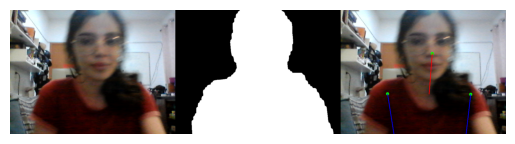

In [30]:
import time

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Erro ao acessar webcam")
    cap.release()
    cv2.destroyAllWindows()
    raise SystemExit

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = None

last_analysis_time = 0.0
analysis_interval = 1.0  # analisar postura a cada 1 segundo
last_landmarks = None
last_mask = None
posture_message = "Aguardando análise..."

# Função auxiliar para desenhar landmarks em um frame

def annotate_frame_with_landmarks(frame, landmarks, mask=None):
    annotated = frame.copy()
    if landmarks:
        annotated = draw_keypoints(annotated, landmarks)
    if mask is not None:
        mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
        annotated = cv2.addWeighted(annotated, 0.75, mask_rgb, 0.25, 0)
    return annotated

while True:
    ret, frame = cap.read()
    if not ret:
        print("Falha ao capturar frame")
        break

    current_time = time.time()
    if current_time - last_analysis_time >= analysis_interval:
        last_analysis_time = current_time
        cv2.imwrite("frame_entrada.png", frame)
        landmarks, mask = process_image_mp_mask("frame_entrada.png", "frame_saida.png")

        if landmarks:
            posture_message = check_posture(landmarks)
            last_landmarks = landmarks
            last_mask = mask
        else:
            posture_message = "Nenhuma pose detectada no frame atual"
            last_landmarks = None
            last_mask = None

        print(f"[{time.strftime('%H:%M:%S')}] {posture_message}")

    annotated_frame = annotate_frame_with_landmarks(frame, last_landmarks, last_mask)
    combined = np.hstack((frame, annotated_frame))

    if out is None:
        height, width = combined.shape[:2]
        out = cv2.VideoWriter('video_analisado.avi', fourcc, 20.0, (width, height))

    out.write(combined)

    cv2.putText(combined, posture_message, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 255), 2)
    cv2.imshow('Vídeo - Pressione "q" para interromper gravação', combined)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        print("Gravação interrompida pelo usuário.")
        break

cap.release()
if out:
    out.release()
cv2.destroyAllWindows()

In [ ]:
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Erro ao acessar webcam")
    exit()

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = None
gravando = False
        
contador = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    combinado = frame.copy()  # Para mostrar o vídeo original ao lado do analisado

    # escrever digite 'a' para analizar a postura e digite w para sair do vídeo
    cv2.imshow('Vídeo - Pressione "a" para analisar postura, "w" para sair', combinado)
    key = cv2.waitKey(30) & 0xFF
    if key == ord('a'):
        print("Analisando postura...")
        cv2.imwrite("frame_entrada.png", frame)  # Salva o frame atual para análise
        landmarks, mask = process_image_mp_mask("frame_entrada.png", "frame_saida.png")
        if landmarks:
            print(check_posture(landmarks))
        else:
            print("Nenhuma pose detectada. Não será gravado.")
    elif key == ord('w'):
        print("Saindo do vídeo...")
        break

    if gravando:
        if out is None:
            height, width, _ = combinado.shape
            out = cv2.VideoWriter('video_analisado.avi', fourcc, 20.0, (width, height))
        out.write(combinado)
        contador += 1
        if contador >= 100:  # Grava por 5 segundos (20 fps * 5s)
            gravando = False
            contador = 0

cap.release()
if out:
    out.release()
cv2.destroyAllWindows()




